# 07 – Comparando Combustibles y Biocombustibles

Las notas de diseño del paquete (`ideias.md`, Dr. Reginaldo G. Leão Jr.,
**GESESC / IFMG**) señalan un caso de uso concreto en investigación: comparar el
desempeño termodinámico del **etanol, gasolina y combustible sostenible de
aviación (SAF)**. Este cuaderno construye esa comparación sobre `pyglenn`.

Evaluamos seis vectores energéticos que abarcan fuentes renovables y fósiles:

| símbolo | especie | papel |
|--------|---------|------|
| H₂ | `H2` | hidrógeno verde |
| CH₄ | `CH4` | gas natural / biometano |
| CH₃OH | `CH3OH` | metanol |
| C₂H₅OH | `C2H5OH` | bioetanol |
| iso-C₈H₁₈ | `C8H18,isooctane` | sustituto de gasolina |
| Jet-A | `Jet-A(g)` | sustituto de queroseno / SAF (≈ C₁₂H₂₃) |

Para cada uno calculamos el poder calorífico, la densidad energética, la demanda
de aire estequiométrica y la intensidad de carbono.

In [1]:
from pyglenn import ThermochemicalCalculator, R

_INDEX = {}

def species_id(calc, name):
    """Devuelve el id en la base de datos de la especie cuyo *nombre* coincide exactamente.

    ``get_available_species`` busca subcadenas tanto en el nombre como en la
    fórmula y limita el resultado a 20 filas, por lo que nombres cortos como
    ``"O2"`` pueden quedar desplazados por entradas como ``"AL2O2"`` o
    ``"CO2"``. Para ser robustos, construimos un índice completo nombre -> id
    una sola vez (almacenado en caché durante la sesión) y buscamos el nombre
    exacto en él.
    """
    if not _INDEX:
        _INDEX.update({s["name"]: s["id"] for s in calc.get_available_species("")})
    if name not in _INDEX:
        raise ValueError(f"Especie {name!r} no encontrada en la base de datos")
    return _INDEX[name]

print("Constante universal de los gases R =", R, "J/(mol.K)")


Constante universal de los gases R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Métricas de combustión para un combustible genérico $C_xH_yO_z$

La combustión completa es

$$C_xH_yO_z + \left(x + \tfrac{y}{4} - \tfrac{z}{2}\right)O_2
   \rightarrow x\,CO_2 + \tfrac{y}{2}\,H_2O.$$

De `pyglenn` obtenemos el PCI (agua gaseosa); de la masa molar obtenemos la
densidad energética gravimétrica; la demanda de aire y la producción de CO₂
siguen de la estequiometría. El aire es 21 % de O₂ en mol, masa molar media
28,97 g/mol.

In [3]:
AIR_M = 28.97          # g/mol
CO2_M = 44.01          # g/mol
O2_PER_AIR = 0.21

FUELS = {
    "H2":              dict(species="H2",              x=0, y=2,  z=0),
    "CH4":             dict(species="CH4",             x=1, y=4,  z=0),
    "CH3OH":           dict(species="CH3OH",           x=1, y=4,  z=1),
    "C2H5OH":          dict(species="C2H5OH",          x=2, y=6,  z=1),
    "isooctane":       dict(species="C8H18,isooctane", x=8, y=18, z=0),
    "Jet-A":           dict(species="Jet-A(g)",        x=12, y=23, z=0),
}

def molar_mass(calc, name):
    sid = species_id(calc, name)
    return calc.db.get_species_data(sid)["molecular_weight"]

def combustion_metrics(calc, species, x, y, z):
    nO2 = x + y / 4 - z / 2
    def H(name, nu, T=298.15):
        return nu * calc.calculate_properties(species_id(calc, name), T)["h_relative"]
    dh = (H("CO2", x) + H("H2O", y / 2)) - (H(species, 1) + H("O2", nO2))
    lhv = -dh                                   # J/mol
    M = molar_mass(calc, species)               # g/mol
    n_air = nO2 / O2_PER_AIR                     # mol aire por mol combustible
    afr_mass = n_air * AIR_M / M                 # kg aire / kg combustible
    lhv_MJ_per_kg = lhv / M / 1000.0
    co2_g_per_MJ = (x * CO2_M) / (lhv / 1e6)     # g CO2 por MJ de energía del combustible
    return dict(M=M, LHV_kJ_mol=lhv / 1000.0, LHV_MJ_kg=lhv_MJ_per_kg,
                AFR=afr_mass, CO2_g_per_MJ=co2_g_per_MJ)

## 2. La tabla comparativa

In [4]:
rows = {}
with ThermochemicalCalculator() as calc:
    for label, f in FUELS.items():
        rows[label] = combustion_metrics(calc, **f)

fuel_df = pd.DataFrame(rows).T
fuel_df = fuel_df.rename(columns={
    "M": "M [g/mol]", "LHV_kJ_mol": "PCI [kJ/mol]", "LHV_MJ_kg": "PCI [MJ/kg]",
    "AFR": "A/C estequiom. [-]", "CO2_g_per_MJ": "CO2 [g/MJ]",
})
print(fuel_df.to_string())

           M [g/mol]  PCI [kJ/mol]  PCI [MJ/kg]  A/C estequiom. [-]  CO2 [g/MJ]
H2             2.016       241.825      119.960              34.216       0.000
CH4           16.042       802.557       50.027              17.198      54.837
CH3OH         32.042       676.218       21.104               6.458      65.083
C2H5OH        46.068     1,277.541       27.731               8.984      68.898
isooctane    114.229     5,100.475       44.652              15.096      69.029
Jet-A        167.311     7,253.421       43.353              14.635      72.810


## 3. Densidad energética gravimétrica

El hidrógeno supera con mucho a cualquier combustible carbonáceo por unidad de
masa; los biocombustibles oxigenados (metanol, etanol) llevan menos energía por
kilogramo que la gasolina o el queroseno porque la molécula del combustible ya
contiene oxígeno.

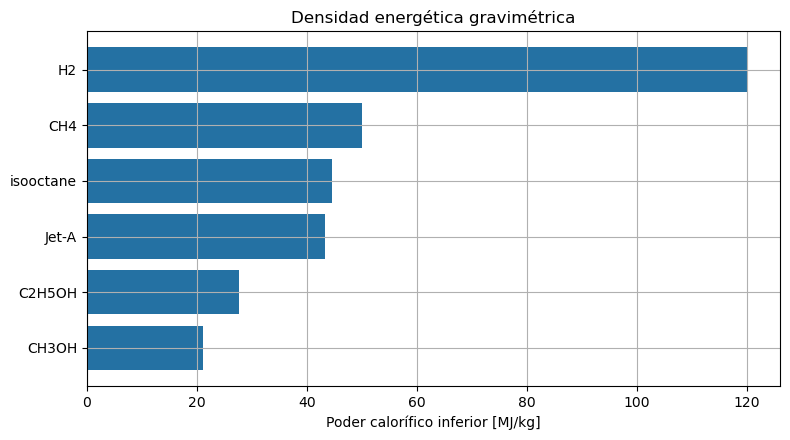

In [5]:
order = fuel_df.sort_values("PCI [MJ/kg]", ascending=True)
fig, ax = plt.subplots()
ax.barh(order.index, order["PCI [MJ/kg]"], color="#2471a3")
ax.set_xlabel("Poder calorífico inferior [MJ/kg]")
ax.set_title("Densidad energética gravimétrica")
fig.tight_layout()
plt.show()

## 4. Intensidad de carbono

CO₂ de combustión directa por unidad de energía entregada. El hidrógeno no emite
nada en el punto de uso; el metano es el hidrocarburo menos intensivo en carbono
(alta relación H:C).

> **Advertencia sobre el ciclo de vida.** Estas son emisiones de *combustión
> directa*. Los combustibles biogénicos (bioetanol, biometano, SAF de biomasa)
> reciclan el CO₂ atmosférico, por lo que su carbono *neto* en el ciclo de vida
> puede ser muy inferior al mostrado aquí — un tema central del trabajo del
> GESESC en energías renovables.

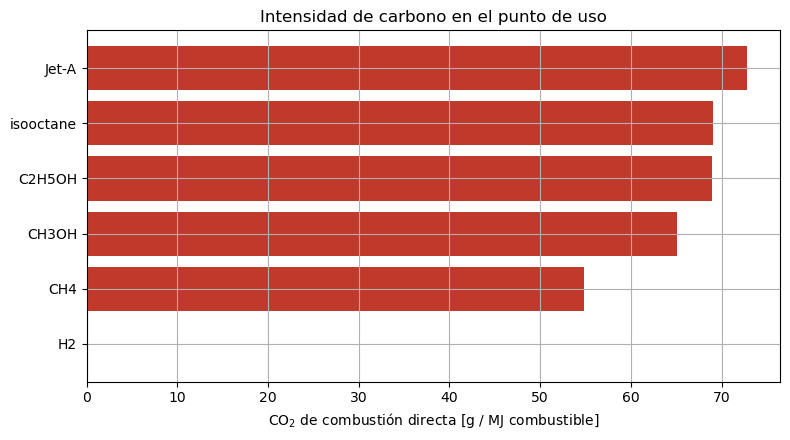

In [6]:
order = fuel_df.sort_values("CO2 [g/MJ]", ascending=True)
colors = ["#27ae60" if v == 0 else "#c0392b" for v in order["CO2 [g/MJ]"]]
fig, ax = plt.subplots()
ax.barh(order.index, order["CO2 [g/MJ]"], color=colors)
ax.set_xlabel("CO$_2$ de combustión directa [g / MJ combustible]")
ax.set_title("Intensidad de carbono en el punto de uso")
fig.tight_layout()
plt.show()

## 5. Relación aire-combustible estequiométrica

La relación A/C dimensiona el sistema de admisión de aire de un motor o
combustor. El hidrógeno y los hidrocarburos puros necesitan mucho aire por
kilogramo de combustible; los combustibles oxigenados necesitan menos porque
llevan su propio oxígeno — relevante para la velocidad de llama y la formación
de NOₓ.

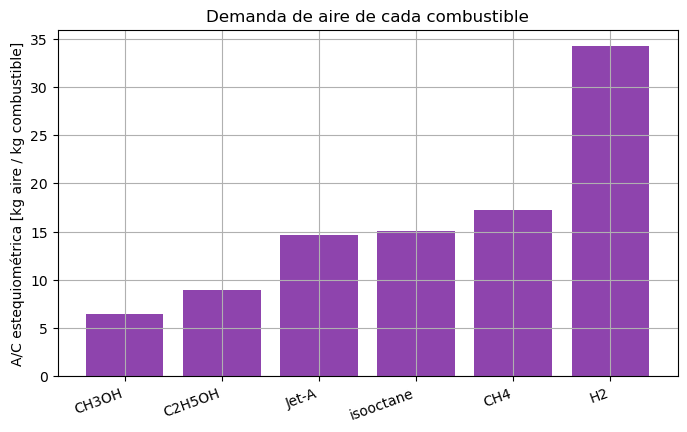

In [7]:
order = fuel_df.sort_values("A/C estequiom. [-]", ascending=True)
fig, ax = plt.subplots()
ax.bar(order.index, order["A/C estequiom. [-]"], color="#8e44ad")
ax.set_ylabel("A/C estequiométrica [kg aire / kg combustible]")
ax.set_title("Demanda de aire de cada combustible")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
plt.show()

## 6. Poder calorífico vs. temperatura

Para etanol e isooctano, trazamos cómo varía el PCI con la temperatura (ley de
Kirchhoff, cuaderno 05). La variación es pequeña — unos pocos por ciento —,
confirmando que los poderes caloríficos a temperatura ambiente son utilizables en
todo el rango de temperaturas relevante para combustores.

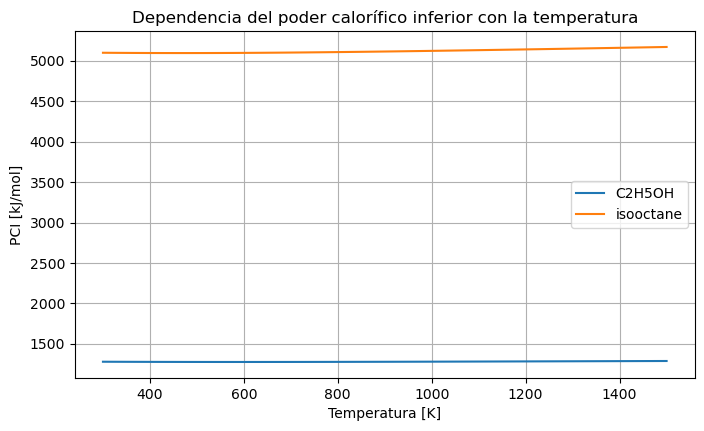

In [8]:
def lhv_at_T(calc, f, T):
    x, y, z = f["x"], f["y"], f["z"]
    nO2 = x + y / 4 - z / 2
    def H(name, nu):
        return nu * calc.calculate_properties(species_id(calc, name), T)["h_relative"]
    dh = (H("CO2", x) + H("H2O", y / 2)) - (H(f["species"], 1) + H("O2", nO2))
    return -dh / 1000.0

Tgrid = np.linspace(300, 1500, 40)
fig, ax = plt.subplots()
with ThermochemicalCalculator() as calc:
    for label in ["C2H5OH", "isooctane"]:
        f = FUELS[label]
        lhv = [lhv_at_T(calc, f, T) for T in Tgrid]
        ax.plot(Tgrid, lhv, label=label)
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("PCI [kJ/mol]")
ax.set_title("Dependencia del poder calorífico inferior con la temperatura")
ax.legend()
plt.show()

## Conclusión

- **Bioetanol / metanol**: renovables y de combustión limpia, pero con densidad
  energética ~35–50 % inferior a la gasolina — aceptable para transporte
  terrestre, penalizante para aviación.
- **Isooctano / Jet-A**: alta densidad energética gravimétrica y volumétrica —
  de ahí el impulso por SAF *drop-in* que iguale las propiedades del queroseno
  reduciendo el carbono en el ciclo de vida.
- **Hidrógeno**: energía por kilogramo inigualable y cero CO₂ en el punto de
  uso, pero sus características de almacenamiento y demanda de aire difieren
  drásticamente de los combustibles líquidos.

`pyglenn` convierte este análisis de compromisos en pocas líneas de código —
exactamente el acceso rápido y programático a datos termoquímicos que defienden
las notas de diseño.

**A continuación:** el cuaderno 08 aborda el equilibrio químico y la energía de
Gibbs.